In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pascal-voc-2012-dataset' dataset.
Path to dataset files: /kaggle/input/pascal-voc-2012-dataset


In [ ]:
import os

image_dir = os.path.join(path, "VOC2012_train_val", "VOC2012_train_val", "JPEGImages")
print(image_dir)

/kaggle/input/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random

# Pick a random image
image_files = os.listdir(image_dir)
image_path = os.path.join(image_dir, random.choice(image_files))

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Initialize selective search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image)

# Use fast mode (~2000 proposals)
ss.switchToSelectiveSearchFast()

rects = ss.process()

print("Total region proposals:", len(rects))

Total region proposals: 806


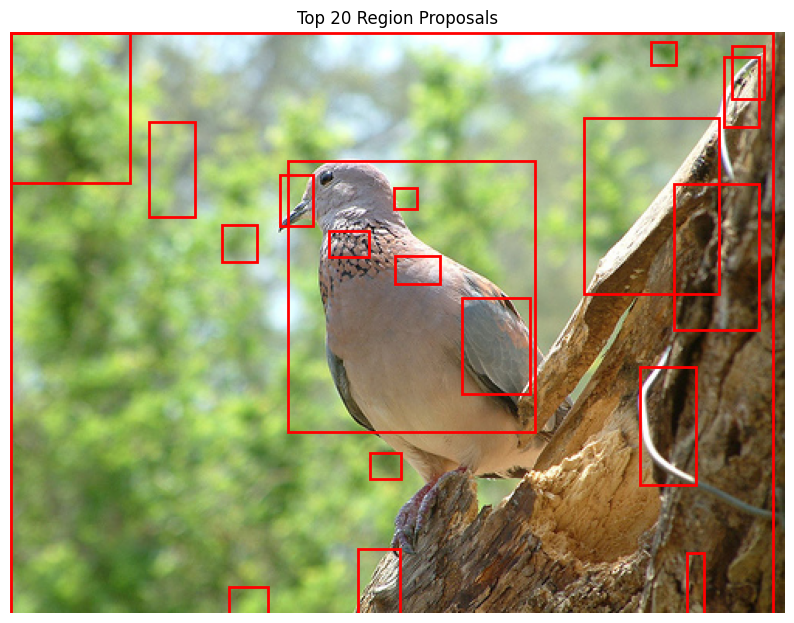

In [ ]:
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(image_rgb)

for i, (x, y, w, h) in enumerate(rects[:20]):
    rect = plt.Rectangle((x, y), w, h,
                         fill=False,
                         edgecolor='red',
                         linewidth=2)
    ax.add_patch(rect)

plt.title("Top 20 Region Proposals")
plt.axis("off")
plt.show()

In [ ]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import cv2
import numpy as np

In [ ]:
model = models.vgg16(pretrained=True)

# Remove final classifier layer
model.classifier = model.classifier[:-1]   # Remove last FC layer

model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

features_list = []

for (x, y, w, h) in rects[:2000]:  # use ~2000 proposals

    # Crop region
    region = image_rgb[y:y+h, x:x+w]

    if region.size == 0:
        continue

    # Transform
    input_tensor = transform(region)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Extract features
    with torch.no_grad():
        feature = model(input_tensor)

    # Flatten feature vector
    feature = feature.view(-1).cpu().numpy()

    features_list.append(feature)

print("Total extracted features:", len(features_list))
print("Feature vector shape:", features_list[0].shape)

Total extracted features: 806
Feature vector shape: (4096,)


In [ ]:
import os
import xml.etree.ElementTree as ET

annotation_dir = os.path.join(path, "VOC2012_train_val", "VOC2012_train_val", "Annotations")

def get_ground_truth_boxes(image_filename):
    xml_file = os.path.join(annotation_dir, image_filename.replace(".jpg", ".xml"))

    tree = ET.parse(xml_file)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text

        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

    return boxes, labels

In [ ]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)

    return iou

In [ ]:
image_filename = os.path.basename(image_path)

gt_boxes, gt_labels = get_ground_truth_boxes(image_filename)

X = []   # features
y = []   # labels (1 positive, 0 negative)

for feature, (x, y_coord, w, h) in zip(features_list, rects[:len(features_list)]):

    proposal_box = [x, y_coord, x + w, y_coord + h]

    max_iou = 0
    for gt_box in gt_boxes:
        iou = compute_iou(proposal_box, gt_box)
        max_iou = max(max_iou, iou)

    if max_iou >= 0.5:
        X.append(feature)
        y.append(1)

    elif max_iou < 0.3:
        X.append(feature)
        y.append(0)

    # ignore 0.3–0.5

In [ ]:
import numpy as np

X = np.array(X)
y = np.array(y)

print("Training samples:", len(X))
print("Positive samples:", sum(y))
print("Negative samples:", len(y) - sum(y))

Training samples: 757
Positive samples: 37
Negative samples: 720


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

svm = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, max_iter=5000)
)

svm.fit(X, y)

print("SVM training complete!")

SVM training complete!


In [ ]:
accuracy = svm.score(X, y)
print("Training Accuracy:", accuracy)

Training Accuracy: 1.0


In [ ]:
def convert_to_xywh(box):
    xmin, ymin, xmax, ymax = box
    w = xmax - xmin
    h = ymax - ymin
    x = xmin + w / 2
    y = ymin + h / 2
    return x, y, w, h

In [ ]:
import numpy as np

def compute_regression_targets(proposal_box, gt_box):

    px, py, pw, ph = convert_to_xywh(proposal_box)
    gx, gy, gw, gh = convert_to_xywh(gt_box)

    tx = (gx - px) / pw
    ty = (gy - py) / ph
    tw = np.log(gw / pw)
    th = np.log(gh / ph)

    return [tx, ty, tw, th]

In [ ]:
X_reg = []
y_reg = []

for feature, (x, y_coord, w, h) in zip(features_list, rects[:len(features_list)]):

    proposal_box = [x, y_coord, x+w, y_coord+h]

    max_iou = 0
    best_gt = None

    for gt_box in gt_boxes:
        iou = compute_iou(proposal_box, gt_box)
        if iou > max_iou:
            max_iou = iou
            best_gt = gt_box

    if max_iou >= 0.5:  # positive only

        targets = compute_regression_targets(proposal_box, best_gt)

        X_reg.append(feature)
        y_reg.append(targets)

X_reg = np.array(X_reg)
y_reg = np.array(y_reg)

print("Regression samples:", len(X_reg))

Regression samples: 37


In [ ]:
from sklearn.linear_model import Ridge

bbox_regressor = Ridge(alpha=1.0)
bbox_regressor.fit(X_reg, y_reg)

print("Bounding Box Regressor trained!")

Bounding Box Regressor trained!


In [ ]:
def apply_bbox_regression(proposal_box, deltas):

    px, py, pw, ph = convert_to_xywh(proposal_box)
    tx, ty, tw, th = deltas

    gx = tx * pw + px
    gy = ty * ph + py
    gw = np.exp(tw) * pw
    gh = np.exp(th) * ph

    xmin = gx - gw / 2
    ymin = gy - gh / 2
    xmax = gx + gw / 2
    ymax = gy + gh / 2

    return [xmin, ymin, xmax, ymax]

In [ ]:
feature = X_reg[0]
proposal_box = [x, y_coord, x+w, y_coord+h]  # example proposal

pred_deltas = bbox_regressor.predict([feature])[0]

refined_box = apply_bbox_regression(proposal_box, pred_deltas)

print("Original:", proposal_box)
print("Refined :", refined_box)

Original: [np.int32(136), np.int32(0), np.int32(467), np.int32(294)]
Refined : [np.float64(127.54094490408897), np.float64(1.928021639585495), np.float64(523.5717725455761), np.float64(418.16340109705925)]


In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
import os

# Select new image
test_image_path = os.path.join(image_dir, random.choice(os.listdir(image_dir)))

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image)
ss.switchToSelectiveSearchFast()

rects = ss.process()
print("Total proposals:", len(rects))

Total proposals: 1090


In [ ]:
test_features = []
proposal_boxes = []

for (x, y, w, h) in rects[:2000]:

    region = image_rgb[y:y+h, x:x+w]
    if region.size == 0:
        continue

    input_tensor = transform(region).unsqueeze(0).to(device)

    with torch.no_grad():
        feature = model(input_tensor)

    feature = feature.view(-1).cpu().numpy()

    test_features.append(feature)
    proposal_boxes.append([x, y, x+w, y+h])

test_features = np.array(test_features)

In [ ]:
scores = svm.decision_function(test_features)
pred_labels = svm.predict(test_features)

In [ ]:
positive_indices = np.where(pred_labels == 1)[0]

boxes = [proposal_boxes[i] for i in positive_indices]
scores = [scores[i] for i in positive_indices]
features_pos = test_features[positive_indices]

In [ ]:
refined_boxes = []

for box, feature in zip(boxes, features_pos):

    deltas = bbox_regressor.predict([feature])[0]
    refined_box = apply_bbox_regression(box, deltas)

    refined_boxes.append(refined_box)

In [ ]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

In [ ]:
def non_max_suppression(boxes, scores, iou_threshold=0.3):

    indices = np.argsort(scores)[::-1]
    keep = []

    while len(indices) > 0:
        current = indices[0]
        keep.append(current)

        remaining = []

        for idx in indices[1:]:
            iou = compute_iou(boxes[current], boxes[idx])
            if iou < iou_threshold:
                remaining.append(idx)

        indices = np.array(remaining)

    return keep

In [ ]:
keep_indices = non_max_suppression(refined_boxes, scores, iou_threshold=0.3)

final_boxes = [refined_boxes[i] for i in keep_indices]
final_scores = [scores[i] for i in keep_indices]

print("Final detections after NMS:", len(final_boxes))

Final detections after NMS: 43


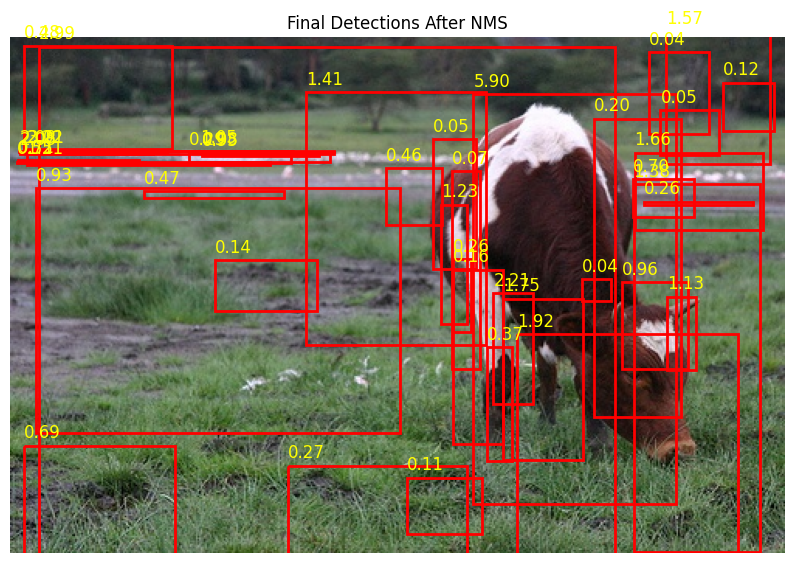

In [ ]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(image_rgb)

for box, score in zip(final_boxes, final_scores):

    xmin, ymin, xmax, ymax = box

    rect = plt.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        edgecolor='red',
        linewidth=2
    )

    ax.add_patch(rect)
    ax.text(xmin, ymin-5, f"{score:.2f}", color='yellow', fontsize=12)

plt.title("Final Detections After NMS")
plt.axis("off")
plt.show()

In [ ]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return interArea / (boxAArea + boxBArea - interArea + 1e-6)

In [ ]:
def compute_precision_recall(pred_boxes, pred_scores, gt_boxes, iou_thresh=0.5):

    sorted_indices = np.argsort(pred_scores)[::-1]
    pred_boxes = [pred_boxes[i] for i in sorted_indices]

    TP = np.zeros(len(pred_boxes))
    FP = np.zeros(len(pred_boxes))
    matched = set()

    for i, pred_box in enumerate(pred_boxes):

        best_iou = 0
        best_gt_idx = -1

        for j, gt_box in enumerate(gt_boxes):
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        if best_iou >= iou_thresh and best_gt_idx not in matched:
            TP[i] = 1
            matched.add(best_gt_idx)
        else:
            FP[i] = 1

    cum_TP = np.cumsum(TP)
    cum_FP = np.cumsum(FP)

    precision = cum_TP / (cum_TP + cum_FP + 1e-6)
    recall = cum_TP / len(gt_boxes)

    return precision, recall

In [ ]:
def compute_ap(precision, recall):

    mrec = np.concatenate(([0.], recall, [1.]))
    mpre = np.concatenate(([0.], precision, [0.]))

    for i in range(len(mpre)-1, 0, -1):
        mpre[i-1] = max(mpre[i-1], mpre[i])

    indices = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[indices+1] - mrec[indices]) * mpre[indices+1])

    return ap

In [ ]:
class_list = [
    'aeroplane', 'bicycle', 'bird', 'boat',
    'bottle', 'bus', 'car', 'cat',
    'chair', 'cow', 'diningtable', 'dog',
    'horse', 'motorbike', 'person', 'pottedplant',
    'sheep', 'sofa', 'train', 'tvmonitor'
]